# 9. Results, counts, and post-processing


## 요약 대상 source notebook

| Source notebook | 중요하게 볼 내용 | 가볍게 볼 내용 |
|---|---|---|
| `1_Retrieve_Experiment_Results.ipynb` | job/result 객체, `get_counts()` | 긴 backend workflow |
| `2_Monitor_Jobs.ipynb` | job 상태 확인, result retrieval | 실제 hardware 대기 과정 |
| `2_Visualize_Quantum_Measurments.ipynb` | counts, histogram | 다양한 plot 옵션 |
| `1_Set_Sampler_options.ipynb` | Sampler V2 result 구조 | 세부 option 전체 |


In [1]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram


## 1. 측정은 classical data를 만든다

측정하지 않으면 일반적으로 `counts`가 생기지 않는다.  
`measure`는 qubit의 결과를 classical bit에 저장한다.


In [2]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

qc.draw("text")


┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

## 2. 실행 결과에서 `counts` 읽기

`counts`는 bitstring을 key로, 관측 횟수를 value로 가지는 dictionary-like object이다.
Qiskit의 bitstring은 보통 왼쪽이 높은 classical bit, 오른쪽이 낮은 classical bit에 해당한다.


In [3]:
backend = BasicSimulator()
job = backend.run(qc, shots=1024)
result = job.result()

counts = result.get_counts()
print(counts)


{'11': 501, '00': 523}


## 5. Histogram으로 보기

`plot_histogram`은 counts 또는 dictionary를 받아 측정 분포를 시각화한다.


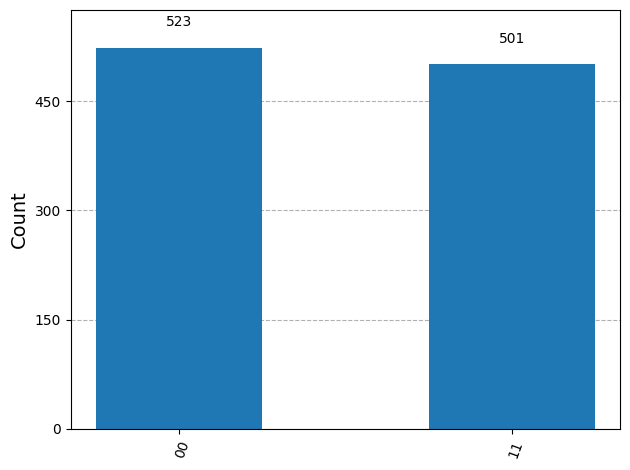

In [4]:
plot_histogram(counts)


## Exercises

**Q1.** `counts = {'00': 512, '11': 512}`일 때 전체 shot 수는?  
 a) 2  
 b) 512  
 c) 1024  
 d) 2048

**Q2.** `counts`를 확률분포로 바꾸는 가장 직접적인 방법은?  
 a) 각 count를 circuit depth로 나눈다.  
 b) 각 count를 전체 shot 수로 나눈다.  
 c) bitstring을 정렬한다.  
 d) `measure_all()`을 다시 호출한다.

**Q3.** `plot_histogram(counts)`의 주된 목적은?  
 a) circuit을 transpile한다.  
 b) 측정 분포를 시각화한다.  
 c) qubit 수를 늘린다.  
 d) gate를 decomposition한다.

**Q4.** `counts`가 생기려면 일반적으로 필요한 것은?  
 a) 측정 instruction  
 b) barrier  
 c) global phase  
 d) circuit name

**Q5.** bit `0`, `1`을 $Z$ 측정 eigenvalue로 바꿀 때 보통 쓰는 대응은?  
 a) `0 -> 0`, `1 -> 1`  
 b) `0 -> +1`, `1 -> -1`  
 c) `0 -> -1`, `1 -> -1`  
 d) `0 -> +i`, `1 -> -i`

**Q6.** Sampler V2 result에서 기존 counts와 비슷한 mapping을 얻는 method는?  
 a) `get_counts()`  
 b) `draw()`  
 c) `decompose()`  
 d) `compose()`

**Q7.** `counts = {'0': 300, '1': 700}`일 때 outcome `'1'`의 확률은?  
 a) 0.3  
 b) 0.5  
 c) 0.7  
 d) 1.0



## Answer key

| Question | Answer | 이유 |
|---|---|---|
| Q1 | c | 512 + 512 = 1024이다. |
| Q2 | b | 확률은 count를 전체 shot 수로 나눈 값이다. |
| Q3 | b | histogram은 측정 outcome 분포를 보여준다. |
| Q4 | a | classical 결과를 얻으려면 측정이 필요하다. |
| Q5 | b | $Z\ket{0}=+\ket{0}$, $Z\ket{1}=-\ket{1}$이다. |
| Q6 | a | `BitArray.get_counts()`가 counts mapping을 만든다. |
| Q7 | c | 700 / 1000 = 0.7이다. |
| Q8 | a | 측정 결과를 이용한 expectation 추정은 대표적인 post-processing이다. |
